In [1]:
import numpy as np
import hyperspy.api as hs

In [2]:
import matplotlib.pyplot as plt
import colorcet as cc
import stem_analysis.plot as saplt

In [3]:
%matplotlib widget

In [4]:
from scipy.interpolate import RBFInterpolator

In [5]:
from skimage.feature import match_template, peak_local_max
from skimage.filters import window
from scipy.ndimage import median_filter, rotate

In [6]:
import os

In [7]:
def median_absolute_deviation(data):
    """
    Calculates the Mean Absolute Deviation (MAD) of a dataset using numpy.
    
    Args:
        data (list or np.array): The input dataset.
        
    Returns:
        float: The mean absolute deviation.
    """
    median = np.median(data)
    absolute_deviations = np.abs(data - median)
    mad = np.median(absolute_deviations)
    return mad

In [8]:
def Karen(dp, window_size):
    """
    Applies the Karen algorithm to an image to enhance features and reduce noise.
    
    Args:
        dp (np.array): The input image data as a 2D numpy array.
        window_size (int): The size of the window for local processing.
        pad_mode (str): The mode for padding the image borders (default is "edge").
        
    Returns:
        np.array: The processed image after applying the Karen algorithm.
    """
    dp_out = dp.copy()

    med = median_filter(dp_out, size=window_size, mode="nearest")
    mad = median_filter(np.abs(dp_out - med), size=window_size, mode="nearest")

    asigma = np.abs(mad*3*1.4826)
    mask = np.logical_or(dp_out < (med - asigma), dp_out > (med + asigma))
    dp_out[mask] = (med+2.2*mad)[mask]
            
    return dp_out

In [9]:
work_dir = "E:/2H-NbSe2 cryo/Centered EFSAED"

In [10]:
dp_path = "E:/2H-NbSe2 cryo/Centered EFSAED/80X_200kV_Stela_0260.dm4"

In [11]:
dp = hs.load(dp_path)
dp.axes_manager

Signal axis name,size,,offset,scale,units
x,512,,-0.0,0.06346283853054047,1/nm
y,512,,-0.0,0.06346283853054047,1/nm


In [12]:
dq = dp.axes_manager[0].scale

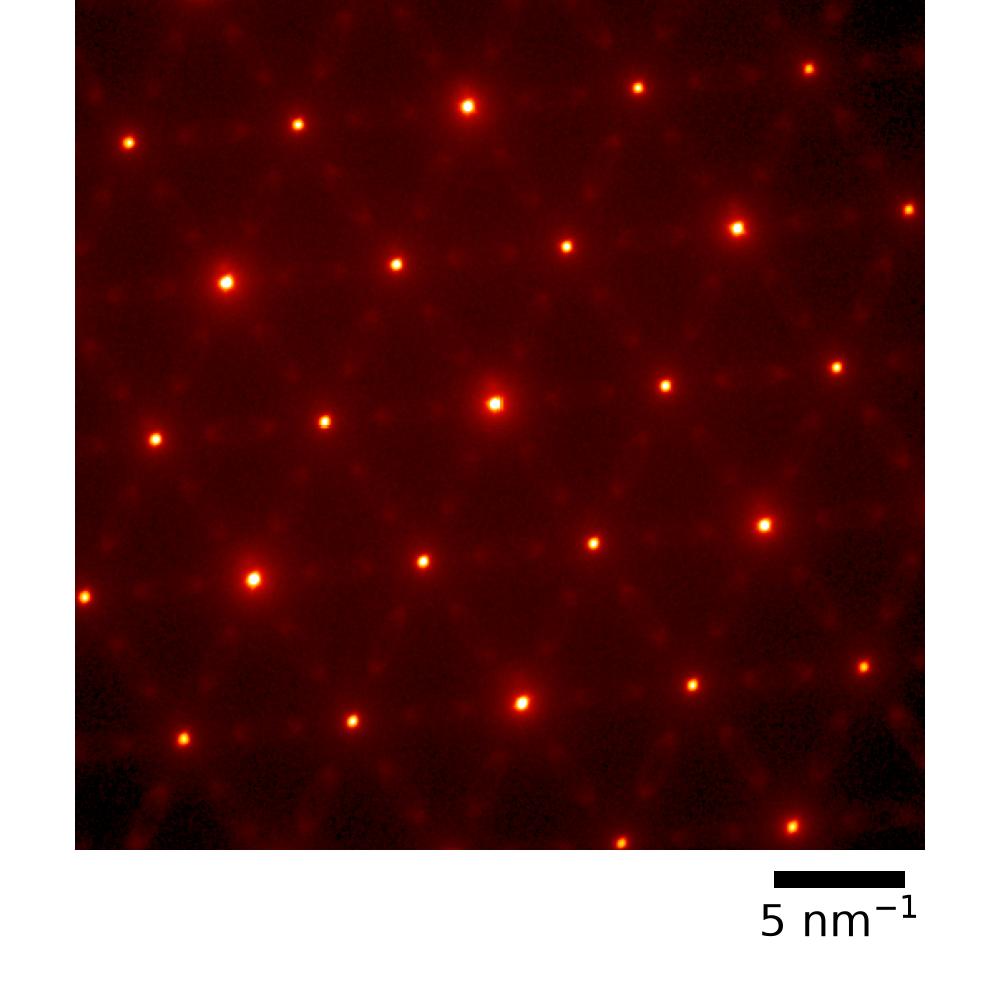

In [13]:
saplt.PlotDiff(dp, dq)
plt.savefig(os.path.join(work_dir, "diff_plot.svg"), dpi = 300, pad_inches = 0, transparent = True)

In [14]:
peaks = peak_local_max(dp.data, min_distance = 5, threshold_rel = 0.005, exclude_border = False)

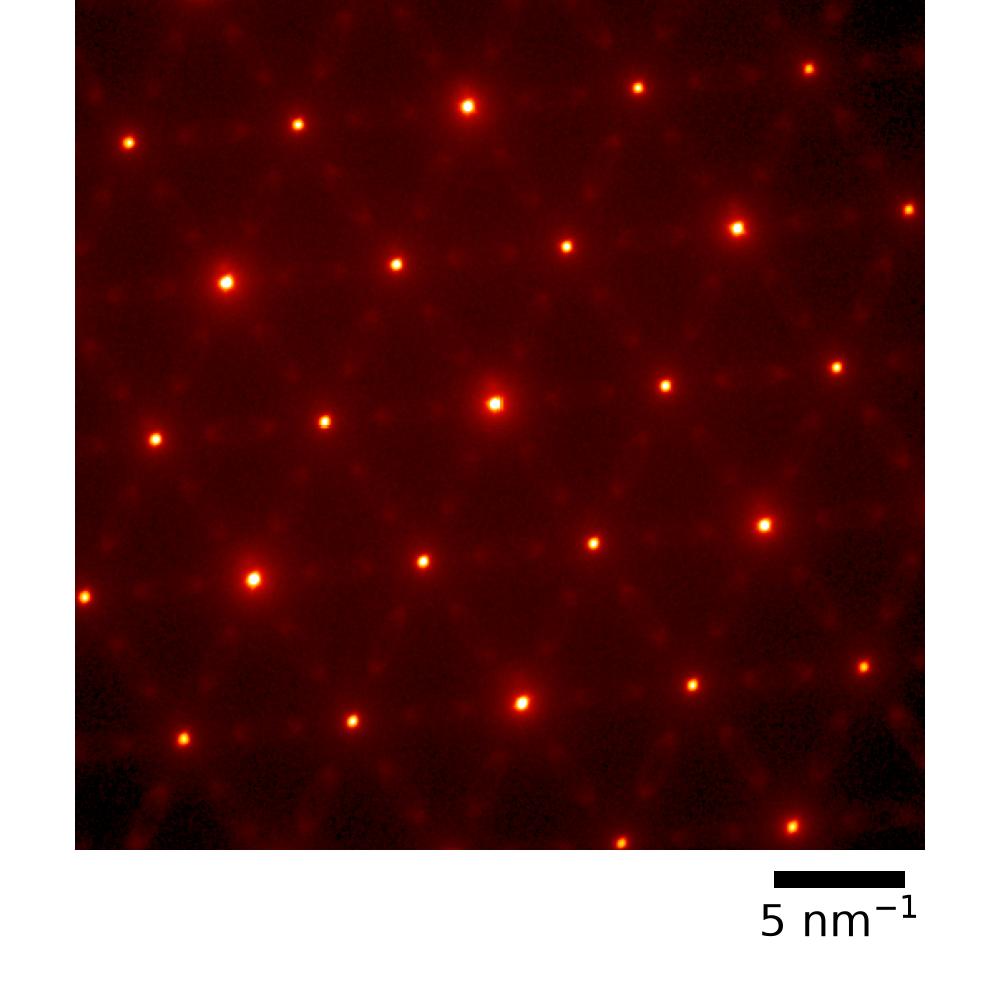

C:\Users\Haoyang Ni\AppData\Local\Temp\ipykernel_29060\670340400.py:3: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(peaks[:, 1], peaks[:, 0], s = 100, c = 'b', marker = 'o', facecolors = 'none', linewidths = 2)


In [15]:
saplt.PlotDiff(dp, dq)
ax = plt.gca()
ax.scatter(peaks[:, 1], peaks[:, 0], s = 100, c = 'b', marker = 'o', facecolors = 'none', linewidths = 2)

In [16]:
def PunchAndFill(dp, peaks, radius):
    rr, cc = np.mgrid[0:dp.shape[0], 0:dp.shape[1]]
    punched = dp.copy().astype(np.float64)
    for peak in peaks:
        mask = (rr - peak[0])**2 + (cc - peak[1])**2 < radius**2
        punched[mask] = np.nan

    target_coords = np.column_stack((rr.ravel(), cc.ravel()))
    valid_mask = ~np.isnan(punched)
    coords = np.column_stack((rr[valid_mask], cc[valid_mask]))
    values = punched[valid_mask]

    missing_mask = ~valid_mask
    missing_coords = np.column_stack((rr[missing_mask], cc[missing_mask]))

    rbf = RBFInterpolator(
        coords,
        values,
        kernel='multiquadric',
        epsilon=2.5,
        smoothing=2.5,
        neighbors=50
    )

    punched_rbf = punched.copy()
    punched_rbf[missing_mask] = rbf(missing_coords)
    
    return punched_rbf
    

    

In [ ]:
punched = PunchAndFill(dp.data, peaks, 20)


In [50]:
karened = Karen(dp.data,50)

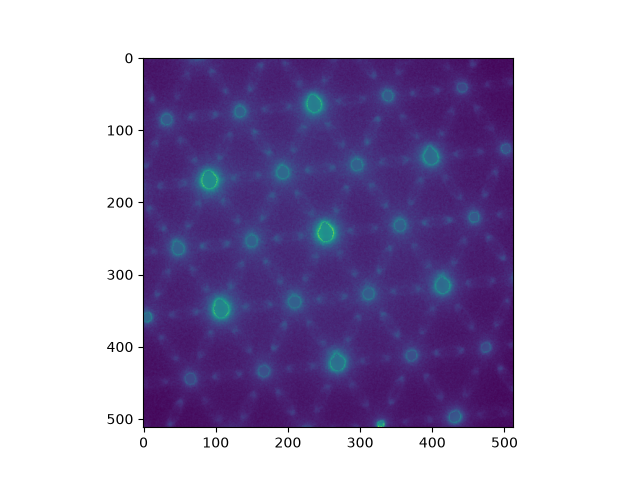

In [51]:
plt.figure()
plt.imshow(karened)

In [52]:
w = window('hann', karened.shape)

In [53]:
dp_diffuse_pad = np.pad(karened*w, 
                        ((punched.shape[0], punched.shape[0]), 
                       (punched.shape[1], punched.shape[1])), 
                      mode='constant')

In [54]:
dpdf = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(dp_diffuse_pad)))

In [55]:
def remove_center(data, radius):
    center = np.array(data.shape) // 2
    y, x = np.ogrid[:data.shape[0], :data.shape[1]]
    mask = (x - center[1])**2 + (y - center[0])**2 <= radius**2
    result = data.copy()
    result[mask] = 0
    return result

In [56]:
dpdf.real

array([[ 1.73213769e+04, -1.21267892e+02, -4.98957308e+04, ...,
        -1.24459018e+05, -4.98957308e+04, -1.21267892e+02],
       [ 2.98256943e+01,  1.78759611e+04,  3.18895186e+03, ...,
        -2.47277541e+05, -1.38296273e+05, -5.28737510e+04],
       [-3.91679904e+04,  1.54473396e+04,  3.59689660e+04, ...,
        -3.96663804e+05, -2.52262740e+05, -1.29515149e+05],
       ...,
       [-7.13553369e+04, -2.00339841e+05, -3.61184482e+05, ...,
         9.26348505e+04,  7.45603480e+04,  2.04205284e+04],
       [-3.91679904e+04, -1.29515149e+05, -2.52262740e+05, ...,
         2.64217139e+04,  3.59689660e+04,  1.54473396e+04],
       [ 2.98256943e+01, -5.28737510e+04, -1.38296273e+05, ...,
        -3.80099666e+04,  3.18895186e+03,  1.78759611e+04]],
      shape=(1536, 1536))

C:\Users\Haoyang Ni\AppData\Local\Temp\ipykernel_29060\894737355.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


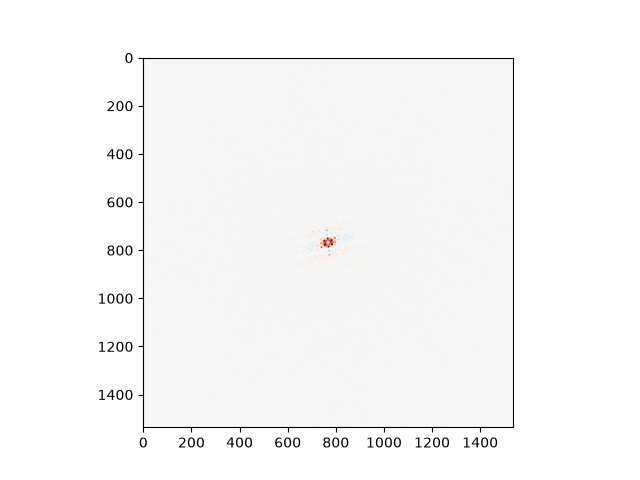

In [57]:
plt.figure()
plt.imshow(remove_center(dpdf.real, 5), vmin = -1e8, vmax = 1e8, cmap = 'RdBu_r')